In [1]:
# some imports
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
plt.rc('font', size=12) 
plt.rc('figure', figsize = (12, 5))

# Settings for the visualizations
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1, rc={"lines.linewidth": 2,'font.family': [u'times']})

import pandas as pd
pd.set_option('display.max_rows', 25)
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_colwidth', 50)

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

# Exploración de datos

In [2]:
train = pd.read_csv("/kaggle/input/ml-ub-2025-project-2/train.csv")
test = pd.read_csv("/kaggle/input/ml-ub-2025-project-2/test_features.csv")


In [4]:
train.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,35,38000,MORTGAGE,20.0,DEBTCONSOLIDATION,B,7500,8.88,0.20,N,7,0
1,1,23,25000,RENT,0.0,DEBTCONSOLIDATION,A,10000,6.54,0.40,N,3,1
2,2,23,48000,RENT,7.0,EDUCATION,B,4000,10.99,0.08,N,3,0
3,3,28,48000,OWN,2.0,MEDICAL,B,3200,11.83,0.07,N,5,0
4,4,23,63000,OWN,7.0,EDUCATION,D,6800,14.54,0.11,Y,4,0


## Que es cada dato 

- id : valor único por columna
- person_age : edad de la persona
- person_income : Ingresos anuales
- person_home_ownership : Tipo de vivienda (RENT o alquiler, MORTGAGE o hipoteca, OWN o propiedad propia, OTHER o otro).
- person_emp_length : Tiempo que lleva en la misma empresa
- loan_intent : Motivo del préstamo (EDUCATION, MEDICAL, etc.).
- loan_grade : Nivel de riesgo (A mejor que G).
- loan_amnt : Cantidad a prestar 
- loan_int_rate : Interés del prestamo
- loan_percent_income : Relación préstamo/ingreso.
- cb_person_default_on_file : Si tuvo impago previo.
- cb_person_cred_hist_length : Antigüedad crediticia (historia financiera de una persona o empresa)
- `TARGET` loan_status : Etiqueta de aprobación del préstamo.


In [5]:
train.isnull().sum()

id                            0
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

===== INFORMACIÓN GENERAL =====
Número de columnas: 13
Número de filas: 43983

=== Columnas de tipo object (strings/objetos) ===


Columna: person_home_ownership
person_home_ownership
RENT        22925
MORTGAGE    18670
OWN          2322
OTHER          66
Name: count, dtype: int64
--> Categorías con frecuencia <20: 0
--> Categorías con frecuencia <10: 0
------------------------------------------------------------

Columna: loan_intent
loan_intent
EDUCATION            9238
MEDICAL              8226
VENTURE              7533
PERSONAL             7504
DEBTCONSOLIDATION    6792
HOMEIMPROVEMENT      4690
Name: count, dtype: int64
--> Categorías con frecuencia <20: 0
--> Categorías con frecuencia <10: 0
------------------------------------------------------------

Columna: loan_grade
loan_grade
A    15805
B    15257
C     8272
D     3780
E      735
F      112
G       22
Name: count, dtype: int64
--> Categorías con frecuencia <20: 0
--> Categorías con frecuencia <10: 0
-----------------------

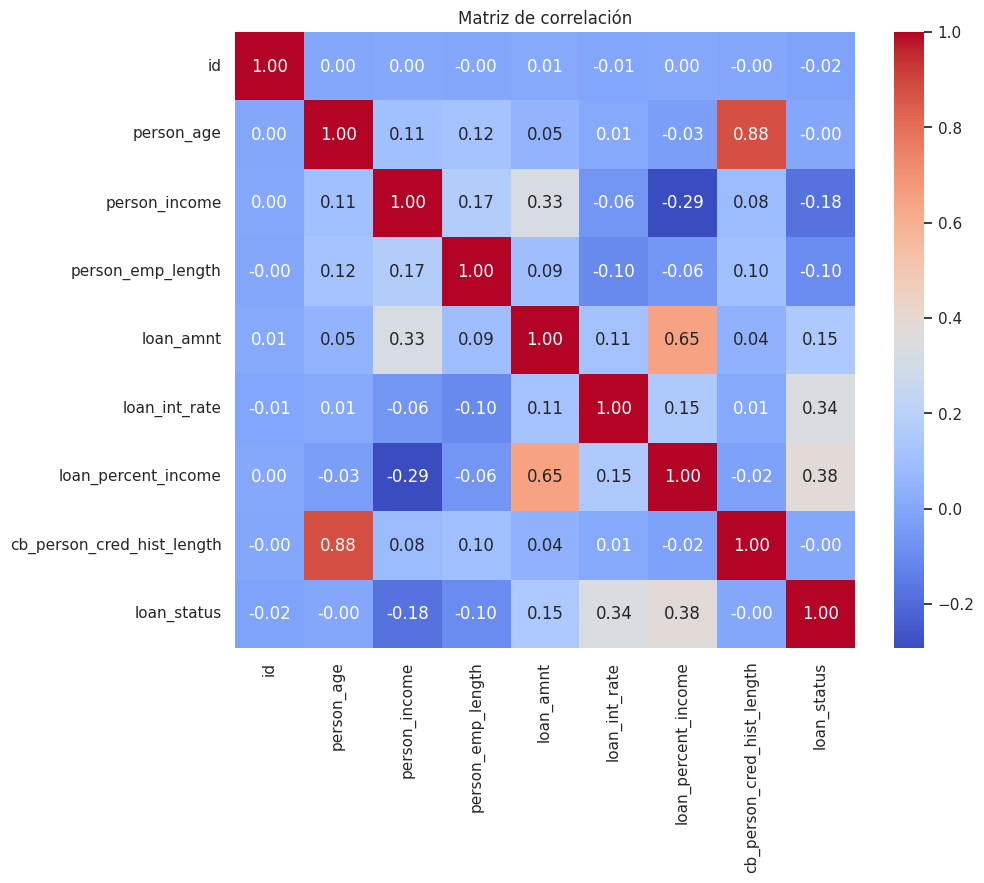


=== Histogramas de columnas numéricas ===


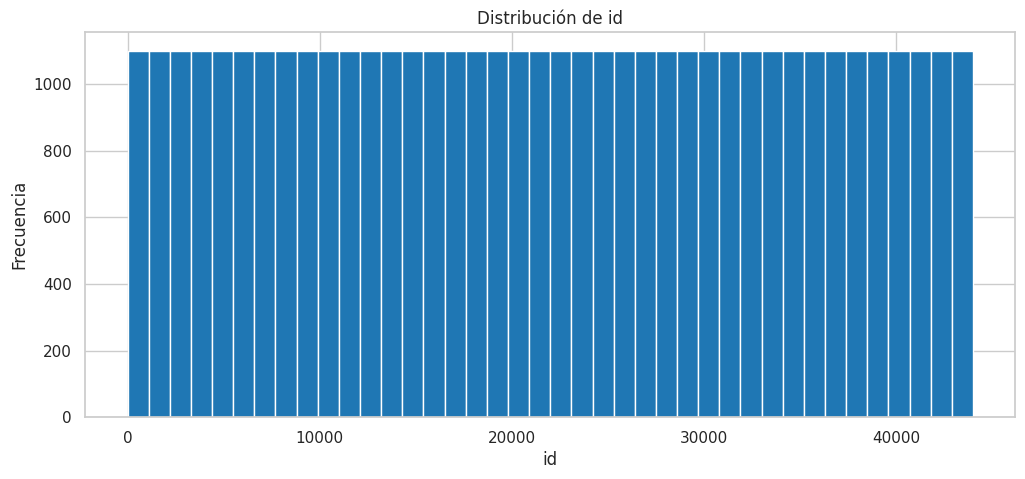

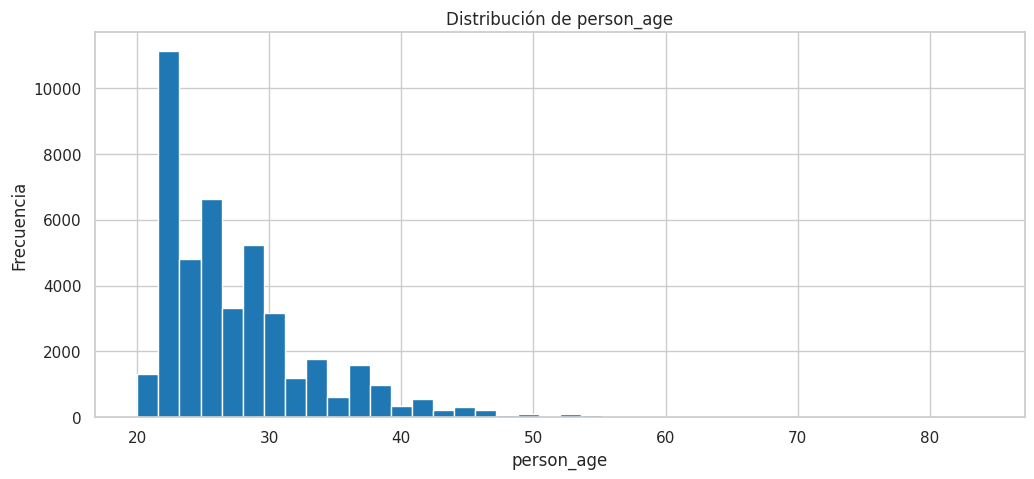

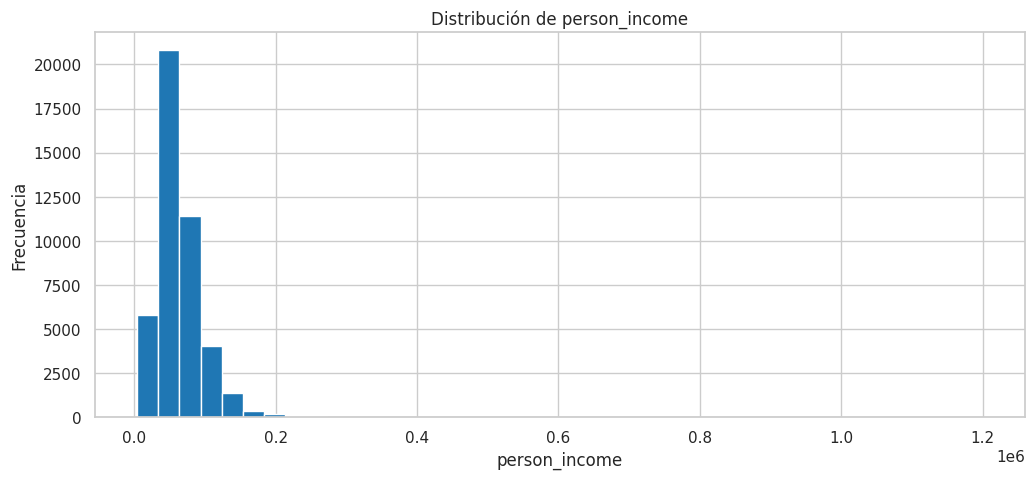

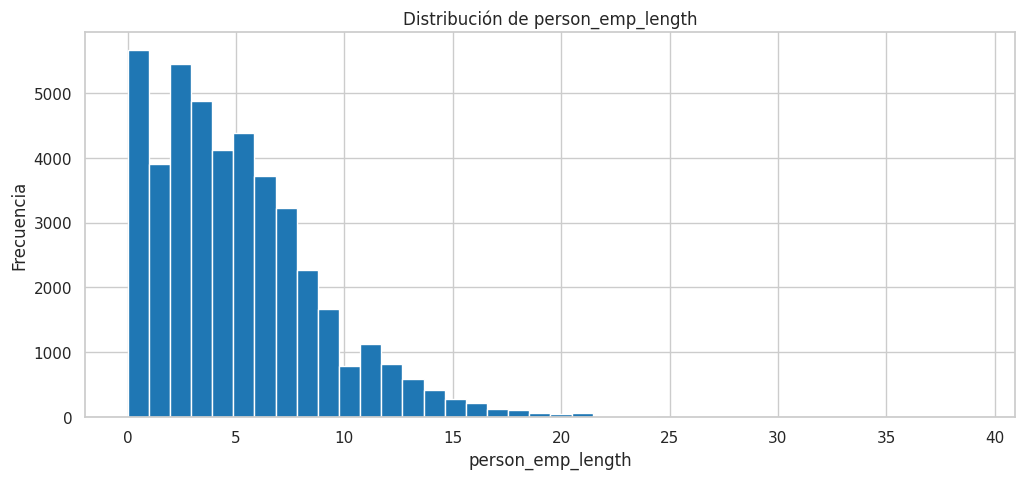

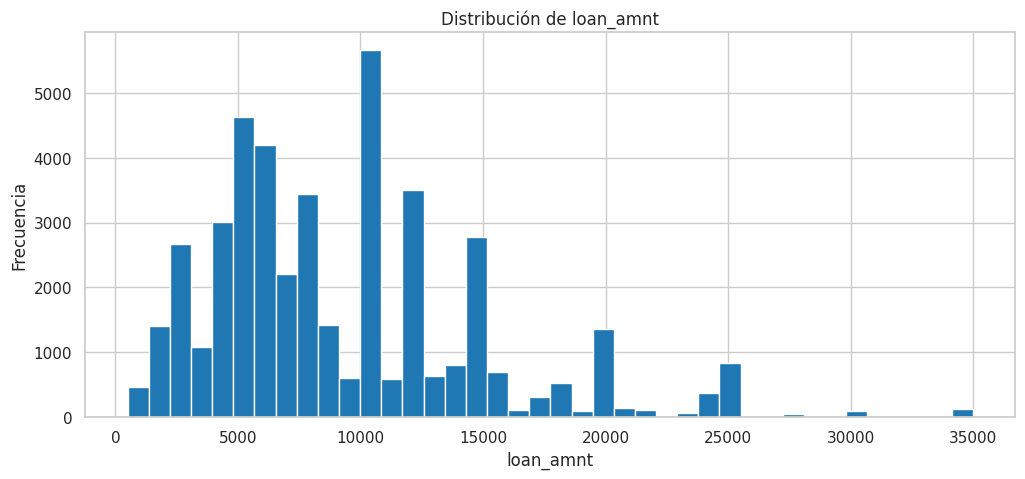

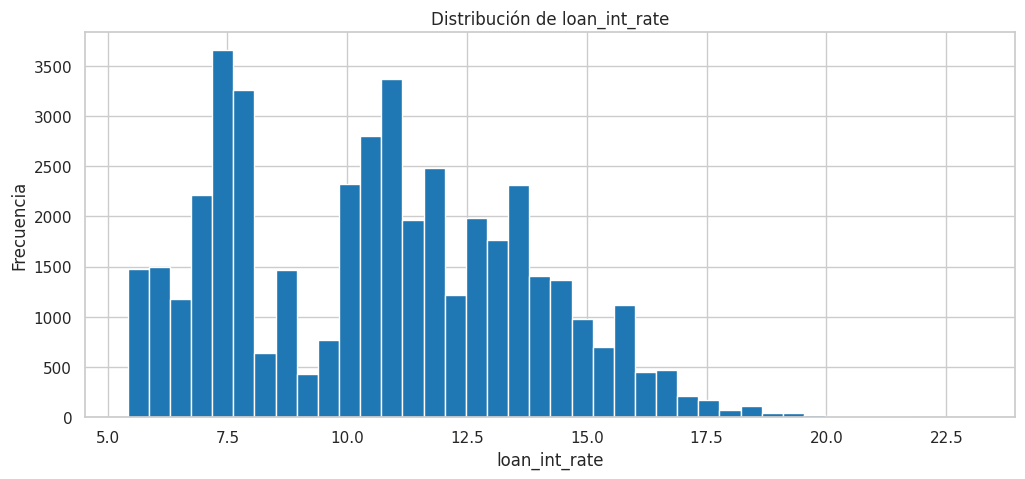

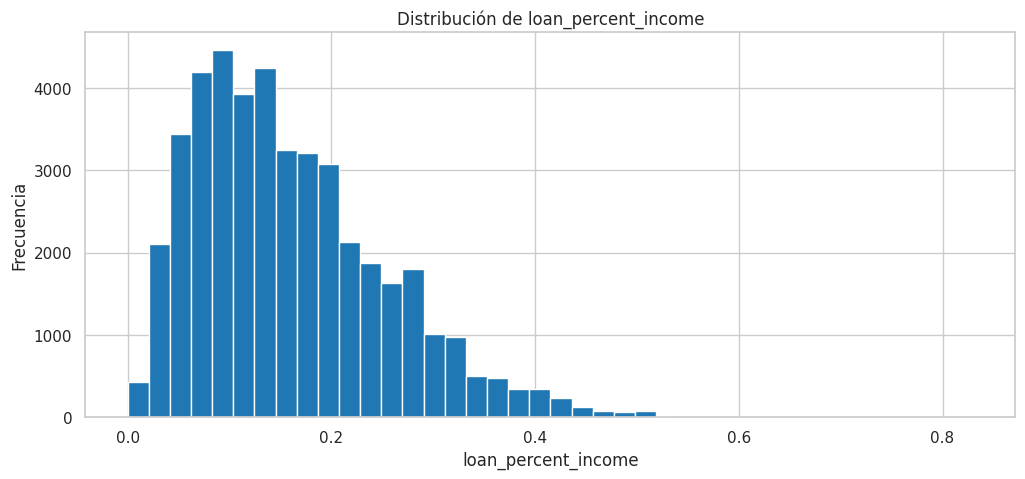

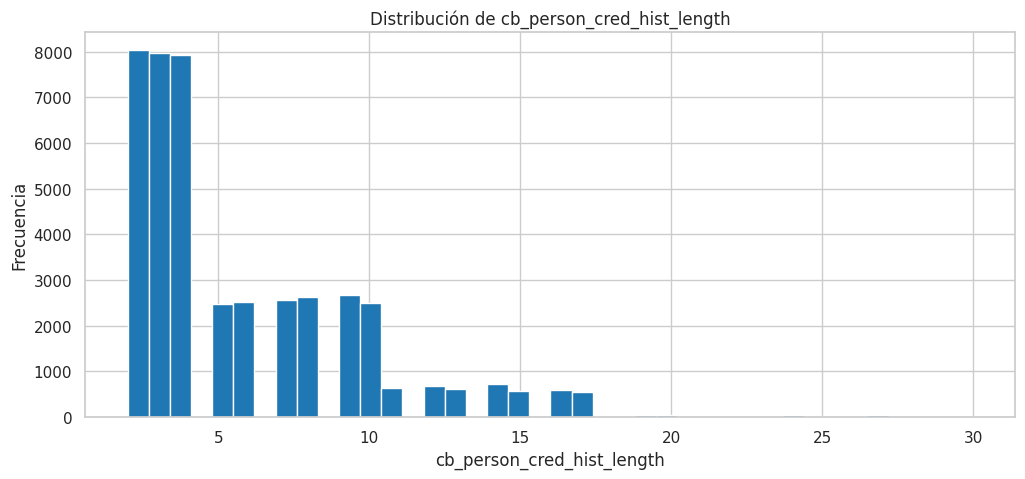

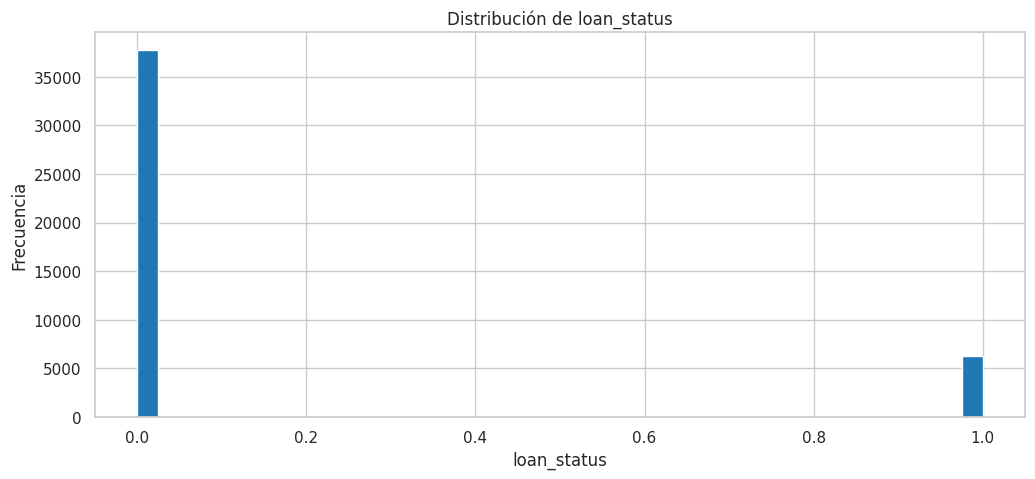


===== FIN DE RESUMEN =====


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_data(df):
    """
    Visualiza un DataFrame:
    - Número de filas y columnas
    - Columnas categóricas y sus frecuencias
    - Cuántas categorías tienen baja frecuencia (<20 y <10)
    - Columnas numéricas con rango y nulos
    - Matriz de correlación y distribuciones numéricas
    """

    print("===== INFORMACIÓN GENERAL =====")
    print(f"Número de columnas: {len(df.columns)}")
    print(f"Número de filas: {len(df)}\n")

    # --- Columnas categóricas ---
    print("=== Columnas de tipo object (strings/objetos) ===\n")
    cat_cols = df.select_dtypes(include=["object", "category"]).columns

    if len(cat_cols) == 0:
        print("No hay columnas categóricas.\n")
    else:
        for col in cat_cols:
            print(f"\nColumna: {col}")
            vc = df[col].value_counts(dropna=False)
            print(vc)
            under_20 = (vc < 20).sum()
            under_10 = (vc < 10).sum()
            print(f"--> Categorías con frecuencia <20: {under_20}")
            print(f"--> Categorías con frecuencia <10: {under_10}")
            print("-" * 60)

    # --- Columnas numéricas ---
    print("\n=== Columnas numéricas (int/float) ===\n")
    num_cols = df.select_dtypes(include=["number"]).columns
    for col in num_cols:
        col_min = df[col].min()
        col_max = df[col].max()
        print(f"Columna: {col} | Min: {col_min:.2f} | Max: {col_max:.2f}")
        if df[col].isnull().sum() > 0:
            print(f"   -> Valores nulos: {df[col].isnull().sum()}")

    # --- Valores nulos ---
    print("\n=== Valores nulos por columna ===")
    print(df.isnull().sum())

    # --- Matriz de correlación ---
    print("\n=== Matriz de Correlación ===")
    if len(num_cols) > 1:
        plt.figure(figsize=(10, 8))
        sns.heatmap(df[num_cols].corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
        plt.title("Matriz de correlación")
        plt.show()
    else:
        print("No hay suficientes columnas numéricas para calcular correlación.\n")

    # --- Histogramas numéricos con nulos o rango amplio ---
    print("\n=== Histogramas de columnas numéricas ===")
    for col in num_cols:
            plt.figure()
            df[col].hist(bins=40)
            plt.title(f"Distribución de {col}")
            plt.xlabel(col)
            plt.ylabel("Frecuencia")
            plt.show()

    print("\n===== FIN DE RESUMEN =====")

visualize_data(train)

# Ver desequilibrio de las clases

In [ ]:
def check_class_balance(df, target_col="loan_status"):
    print("\n=== Distribución de la variable objetivo ===")
    counts = df[target_col].value_counts()
    total = len(df)
    for k, v in counts.items():
        print(f"Clase {k}: {v} ({v/total:.2%})")

    plt.figure(figsize=(6, 4))
    sns.barplot(x=counts.index, y=counts.values, palette="viridis")
    plt.title("Distribución de clases (loan_status)")
    plt.xlabel("Estado del préstamo")
    plt.ylabel("Frecuencia")
    plt.show()


In [ ]:
check_class_balance(train)


# Limpieza de los datos

Una vez vista todos los datos de nuestro dataset los limpiamos para nuestro SVM

# Acciones a realizar para cada columna

## Columnas Numericas

Todas estas columnas tienen que estar estandarizadas ya que el SVM mide distancias y las magnitudes (por ejemplo, 5 000 vs. 35 000) afectarían la frontera de decisión si no están en la misma escala que otras variables. Después de ajustar escalas logarítmicas, todas las variables numéricas deben ser estandarizadas, porque SVM usa distancias en el espacio de características.

### id 

- valor único por columna
- Es un simple índice, no aporta información. Lo borramos del modelo

### person_age 

- edad de la persona
- La mayoria de filas estan situadas entre 20 y 50 (valor máximo se encuentra en 84). Sesgo leve, rango pequeño (20–80)
- No aplicamos logaritmo 

### person_income 

- salario de la persona
- Escala muy amplia (min 4_200 - max 1_200_000.00)
- Aplicar logaritmo 

### person_emp_length 

- Tiempo que lleva en la misma empresa
- Sesgo leve con rango pequeño (0–39)
- Probar a ver si mejora o no la escala logaritmica 

### loan_amnt  

- Cantidad a prestar
- Valores de 500 a 35_000 hay poco sesgo a la izquierda
- No aplicamos logaritmo 

### loan_int_rate 

- Interés del prestamo
- Distribución equilibrada con valores de 5 a 23
- Poco sesgo no aplicar logaritmo

### loan_percent_income 

- Relación préstamo/ingreso.
- Muchos valores pequeños (0–0.2) y pocos grandes (hasta 0.8),
- Aplicar escala logaritimca


### cb_person_cred_hist_length 

- Antigüedad crediticia (historia financiera de una persona o empresa)
- La mayoría de los clientes tiene historiales cortos (2–5 años), y pocos tienen historiales largos (15–30 años) con fuertes outliers
- Aplicar logaritmo

### `TARGET` loan_status : 

- Etiqueta de aprobación del préstamo. No es un valor númerico como tal , es una etiqueta de si o no


## Categoricas

En las columnas con pocos valores posibles aplicamos one hot encoding. Si dejamos las categorías como números “arbitrarios” (por ejemplo, RENT=1, OWN=2, MORTGAGE=3), el modelo asumirá que existe una distancia o jerarquía entre ellas, lo cual no es cierto.

### person_home_ownership 

- tipo de propiedad que tiene la persona
- Valores posibles 4 (RENT, MORTGAGE, OWN, OTHER)
- One hot encoding

### loan_intent 

- Motivo del préstamo
- Valores posibles 6 (EDUCATION, MEDICAL, VENTURE, PERSONAL, DEBTCONSOLIDATION, HOMEIMPROVEMENT)
- One hot encoding
  
### loan_grade 

- Nivel de riesgo (A mejor que G)
- Valores posibles (A a G)
- Probal ordinal encoding y one hot, al ser categorías que tienen un orden o clasificación natural

### cb_person_default_on_file 

- Si tuvo impago previo
- Valores posibles (Y/N)
- Mapeo simple a 1 o 0

# Separar train en train y validation

Estratificamos porque garantiza que tanto el conjunto de entrenamiento como el de validación tengan la misma proporción de clases que el dataset original. Así se evita que el modelo aprenda o evalúe con una distribución distorsionada y obtengas métricas más realistas y comparables.

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Cargar los datos
train = pd.read_csv("/kaggle/input/ml-ub-2025-project-2/train.csv")
test = pd.read_csv("/kaggle/input/ml-ub-2025-project-2/test_features.csv")

# Separar etiquetas
target_col = "loan_status"

# Dividir en train/validation (estratificado)
train_set, valid_set = train_test_split(
    train,
    test_size=0.2,
    stratify=train[target_col],
    random_state=42
)

# Reiniciar índices para evitar duplicados o confusión
train_set = train_set.reset_index(drop=True)
valid_set = valid_set.reset_index(drop=True)

# Verificar equilibrio de clases
print("Distribución en TRAIN:")
print(train_set[target_col].value_counts(normalize=True))
print("\nDistribución en VALIDATION:")
print(valid_set[target_col].value_counts(normalize=True))


Distribución en TRAIN:
loan_status
0    0.857614
1    0.142386
Name: proportion, dtype: float64

Distribución en VALIDATION:
loan_status
0    0.857679
1    0.142321
Name: proportion, dtype: float64


# Aplicar limpieza

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def clean_datasets(train, valid, test):
    """
    Limpia los tres datasets (train, valid, test) siguiendo las reglas dadas:
      - Elimina 'id'
      - Aplica logaritmo donde corresponde
      - Hace One Hot Encoding de las categóricas
      - Escala las numéricas
    Evita leakage: el escalador y el encoder se ajustan solo con TRAIN.
    Devuelve los tres DataFrames listos para entrenar SVM.
    """

    # Copias de seguridad
    train = train.copy()
    valid = valid.copy()
    test  = test.copy()

    # ---- 1️Eliminar id ----
    if 'id' in train.columns:
        train = train.drop(columns=['id'])
        valid = valid.drop(columns=['id'])
        test  = test.drop(columns=['id'])

    # ---- Mapear la binaria cb_person_default_on_file a 1 o 0 ----
    for df in [train, valid, test]:
        df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'Y':1, 'N':0}).astype(int)

    # ---- Función de logaritmo ----
    def apply_log(df, col):
        return np.log1p(df[col])

    # columnas a aplicar el logaritmo
    log_cols = ['person_income', 'loan_percent_income', 'cb_person_cred_hist_length']
    for col in log_cols:
        for df in [train, valid, test]:
            df[col] = apply_log(df, col)

    # PARA TESTEAR  person_emp_length_log a ver si va mejor o no
    # for df in [train, valid, test]:
    #     df["person_emp_length_log"] = np.log1p(df["person_emp_length"])


    
    # ----  One Hot Encoding de las categóricas ----
    cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade']
    encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)  # crear columna por tipo eliminando 1 (evitar colinealidad perfecta)
    # handle unknown -- si aparece en valid/test una categoría no vista en train, no falla; pone ceros en todas las dummies de esa variable.
    # sparse output -- devuelve matriz densa (útil para pasarlo a DataFrame fácilmente)
    
    encoder.fit(train[cat_cols])  # solo con TRAIN aprendes las categorías solo del train para evitar data leakage

    # Transformar y unir al resto de columnas
    def encode_and_join(df):
        encoded = pd.DataFrame(encoder.transform(df[cat_cols]),
                               columns=encoder.get_feature_names_out(cat_cols),
                               index=df.index)
        df = df.drop(columns=cat_cols) # eliminar columnas originales
        return pd.concat([df, encoded], axis=1)

    train = encode_and_join(train)
    valid = encode_and_join(valid)
    test  = encode_and_join(test)



    
    # ---- Estandarizar columnas numéricas ----
    num_cols = [
        'person_age', 'person_income', 'person_emp_length',
        'loan_amnt', 'loan_int_rate', 'loan_percent_income',
        'cb_person_cred_hist_length'
    ]

    scaler = StandardScaler()
    scaler.fit(train[num_cols])  # solo con TRAIN

    for df in [train, valid, test]:
        df[num_cols] = scaler.transform(df[num_cols])

    return train, valid, test

train_clean, valid_clean, test_clean = clean_datasets(train_set, valid_set, test)

In [9]:
# Ver resultados y distribuciones
# visualize_data(train_clean)

# Creación del modelo SVM 

Un SVM (Support Vector Machine) busca una frontera óptima que separe las clases en el espacio de características.
En vez de preocuparse por todos los puntos, se centra solo en los puntos más difíciles de separar, llamados support vectors (vectores de soporte).
Estos son los puntos que “definen” la frontera de decisión.

### En el caso lineal

El modelo busca un hiperplano (una recta si tienes 2 variables, un plano si tienes 3, etc.) que:

- Separe las clases lo mejor posible.
- Maximice el margen (la distancia entre el hiperplano y los puntos más cercanos de cada clase).

Objetivo:
- Maximizar el margen → mejor generalización.

Si los datos son perfectamente separables, el SVM lineal encuentra una línea clara entre ambas clases.
Si no lo son, permite algunos errores (controlados por el parámetro C).

### En el caso no lineal (kernel SVM)

A veces los datos no se pueden separar con una línea recta.
Ahí entra el truco del kernel:
transforma los datos a un espacio de mayor dimensión donde sí pueden separarse linealmente.

Ejemplo:

- En 2D no puedes separar un círculo dentro de otro con una línea.
- Pero en 3D (añadiendo una dimensión extra), sí puedes hacerlo con un plano.

El kernel (como rbf, poly, o sigmoid) se encarga de esa transformación sin tener que calcularla explícitamente (es la llamada kernel trick).

# Parametros 

## C

Penaliza los errores
- C alto → busca separar todo (puede sobreajustar). 
- C bajo → permite más errores (modelo más suave).

## kernel	

- Tipo de frontera	'linear', 'rbf', 'poly'
- define la forma de la frontera.

## gamma

- Afecta a los kernels no lineales (como RBF)
- Controla cuánto influye cada punto de entrenamiento. Gamma alto → fronteras complejas; gamma bajo → más suaves.

## class_weight

- Ajusta el peso de las clases
- Muy útil cuando las clases están desequilibradas. 'balanced' hace que el SVM compense automáticamente la clase minoritaria.



# Estrategias para controlar el desequilibrio

Nuestro dataset tiene muchos prestamos denegados y pocos aprobados, creando un desequilibrio bastante notable

Vistos antes en la exploración de datos : 
``` 
    === Distribución de la variable objetivo ===
    Clase 0: 37721 (85.76%)
    Clase 1: 6262 (14.24%)
```

Si se entrena un SVM sin más, el modelo tenderá a predecir siempre la clase mayoritaria.

### Opciones para corregir esto

1. Usar pesos de clase

Simplemente usar `SVC(class_weight='balanced')` . Esto hace que los errores en la clase minoritaria “pesen” más.

2. Re-muestreo de datos

En esta práctica no lo usaremos, la gracia es usar los datos que nos han dado y no expandir ni reducir para la competición

3. Elegir métricas adecuadas

No usar “accuracy”, porque puede ser engañosa (un modelo que predice todo 0 puede tener 80% de accuracy si las clases están desbalanceadas).
Usar métricas que consideren el desequilibrio, como AUC-ROC, recall, precision, o F1.

Nosotros usaremos `SVC(class_weight='balanced')`para combatir el desbalance y el AUC-ROC como metrica. Es una metrica que mide como de bien separa positivos y negativos.


Para evaluar el AUC-ROC tendremos en cuenta el valor que nos da. 0.5 = azar, 1.0 = perfecto.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed, interact_manual
from sklearn.datasets import make_blobs

from sklearn.svm import SVC
from sklearn import datasets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, roc_curve, classification_report


# Nombre de los datasets limpios para usar 
# train_clean, valid_clean, test_clean

In [12]:
target = "loan_status"
feat_cols = [c for c in train_clean.columns if c != target]

X_train = train_clean[feat_cols].values
y_train = train_clean[target].values

X_valid = valid_clean[feat_cols].values
y_valid = valid_clean[target].values

clf = SVC(
    kernel="linear",
    probability=True,        # necesario para AUC y curva ROC
    class_weight="balanced", # maneja el desbalance
    random_state=42
)

# Para entrenar
X_train_sample = X_train
y_train_sample = y_train
clf.fit(X_train_sample, y_train_sample)

# clf.fit(X_train, y_train)


SVC(class_weight='balanced', kernel='linear', probability=True, random_state=42)

Fitting 2 folds for each of 6 candidates, totalling 12 fits

Millor paràmetre: {'svc__C': 1, 'svc__class_weight': 'balanced', 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Millor puntuació (average_precision): 0.7953

Classification report sobre validació:
              precision    recall  f1-score   support

           0     0.9629    0.9206    0.9413      7545
           1     0.6216    0.7859    0.6942      1252

    accuracy                         0.9014      8797
   macro avg     0.7922    0.8533    0.8177      8797
weighted avg     0.9143    0.9014    0.9061      8797



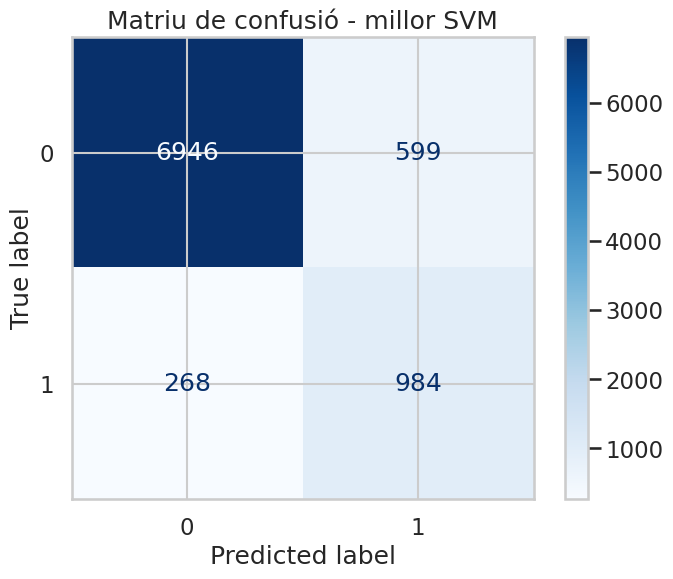

ROC AUC:  0.9174
PR AUC:   0.7884


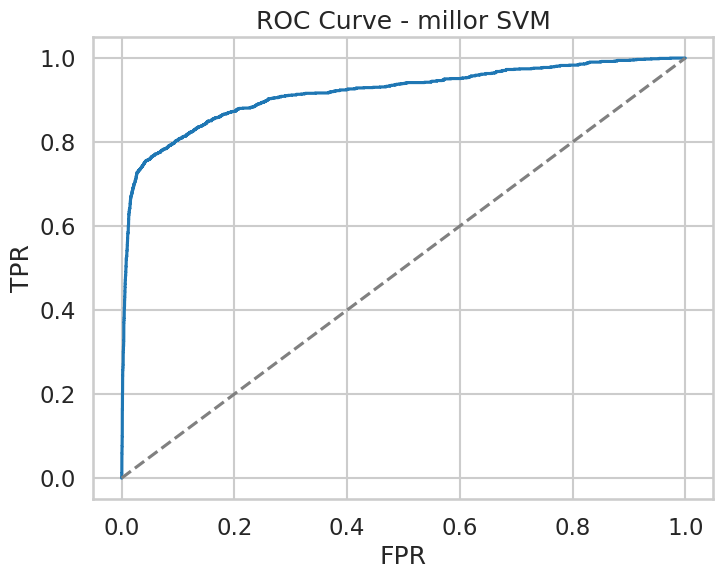

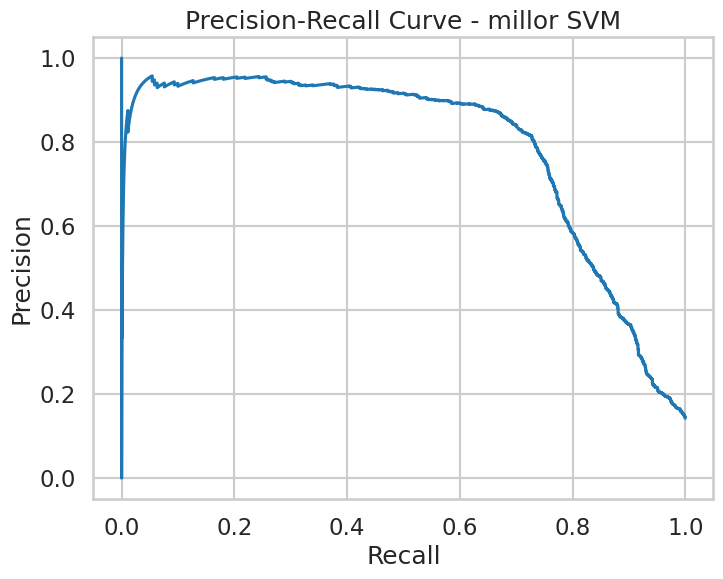

Distribució a validació: {0: 7545, 1: 1252}


In [13]:
# Imports i configuració inicial
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             average_precision_score, precision_recall_curve, roc_curve,
                             ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import seaborn as sns

# Configuració visual
sns.set_context("talk")
plt.rcParams["figure.figsize"] = (8, 6)

# Pipeline base: escalat + SVM 
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=True))
])

# Grid més reduït per velocitat 
# Manté només els valors més típics i representatius
param_grid = [
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.1, 1, 10],                     # menys valors
        "svc__class_weight": ["balanced"]
    },
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.1, 1, 10],
        "svc__gamma": ["scale"],               # només un valor
        "svc__class_weight": ["balanced"]
    }
]

# Mètrica i configuració del GridSearch 
scoring = "average_precision"  # bona per dades desbalancejades
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,      # utilitza tots els nuclis
    verbose=2,
    refit=True
)

# Executar la cerca 
grid.fit(X_train_sample, y_train_sample)

print("\nMillor paràmetre:", grid.best_params_)
print("Millor puntuació ({}): {:.4f}".format(scoring, grid.best_score_))

# Avaluació sobre validació 
y_val_pred = grid.predict(X_valid)
y_val_proba = grid.predict_proba(X_valid)[:, 1]

print("\nClassification report sobre validació:")
print(classification_report(y_valid, y_val_pred, digits=4))

# Matriu de confusió
cm = confusion_matrix(y_valid, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Matriu de confusió - millor SVM")
plt.show()

# Mètriques addicionals
roc_auc = roc_auc_score(y_valid, y_val_proba)
pr_auc = average_precision_score(y_valid, y_val_proba)
print(f"ROC AUC:  {roc_auc:.4f}")
print(f"PR AUC:   {pr_auc:.4f}")

# Curva ROC
fpr, tpr, _ = roc_curve(y_valid, y_val_proba)
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve - millor SVM")
plt.grid(True)
plt.show()

# Curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_valid, y_val_proba)
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - millor SVM")
plt.grid(True)
plt.show()

# Distribució de classes a validació
unique, counts = np.unique(y_valid, return_counts=True)
print("Distribució a validació:", dict(zip(unique, counts)))


# Evaluación del modelo

El GrdiSearchCV ha determinado que la mejor configuración es:

    svc__kernel = 'rbf'
    svc__C = 1
    svc__gamma = 'scale'
    svc__class_weight = 'balanced'

Esto significa que el mejor modelo es un SVM con kernel RBF, no lineal, con regularización suave (C=1) y con ponderación de clases balanceada para gestionar el desbalanceo entre 0 y 1. Este modelo crea una frontera de decisión no lineal y ajusta de forma automática el peso de cada clase para compensar la desproporción presente en los datos.

 1. Resultados de validación:

El proceso de validación ha obtenido una precisión media (average_precision) de 0.7953 durante la búsqueda de hiperparámetros, y posteriormente, al evaluar el modelo sobre el conjunto de validación completo, se han obtenido las siguientes métricas:

ROC AUC = 0.9174
Un valor muy cercano a 1 indica que el modelo separa muy bien las dos clases y tiene una alta capacidad de discriminación entre positivos y negativos.

PR AUC = 0.7884
Esta métrica es especialmente relevante en problemas desbalanceados. Un valor cercano a 0.79 confirma que el modelo mantiene una buena relación entre precisión y recall al detectar la clase minoritaria.

Accuracy = 0.9014
Aunque la exactitud es alta, no es la mejor métrica cuando las clases están desbalanceadas, por lo que también se analiza el detalle por clase.


 2. Classification Report:

Para la calse negativa (0):
    Precisión: 0.9629
    Recall: 0.9206
    F1-score: 0.9413
    La clase 0 es mayoritaria y el modelo la identifica con mucha precisión y un recall elevado, lo que indica pocos falsos positivos y pocos falsos negativos.

Para la clase positiva (1):
    Precision: 0.6216
    Recall: 0.7859
    F1-score: 0.6942
    Aunque la precisión sea menor (hay algunos falsos positivos), el recall es alto. Esto significa que el modelo detecta una gran proporción de casos positivos reales, lo cual es importante al tratarse de la clase minoritaria.

 3. Matriz de confusión:

Se han predecido 6946 ceros reales como ceros, y 599 como unos. En el caso de los unos, se han predecido 265 unos reales como ceros, y 987 como unos.
Por lo tanto, el modelo clasifica correctamente la mayor parte de los negativos (6946), pero también identifica 987 positivos reales, lo cual es una cantidad significativa dada la medida reducida de la clase minoritaria, y aunque haya 265 falsos negativos, la proporcion es relativamente baja comparada con el total de positivos.

 4. Interpretación final:

En conclusion, el modelo seleccionado muestra un rendimiento global muy satisfactorio y es capaz de detectar la clase positiva con una eficacia notable, manteniendo al mismo tiempo una buena precisión general. Por tanto, se considera un modelo adecuado y equilibrado para el problema abordado.

# Evaluar el modelo

AUC-ROC (valid): 0.9174

Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0      0.952     0.976     0.964      7545
           1      0.831     0.704     0.763      1252

    accuracy                          0.938      8797
   macro avg      0.892     0.840     0.863      8797
weighted avg      0.935     0.938     0.935      8797



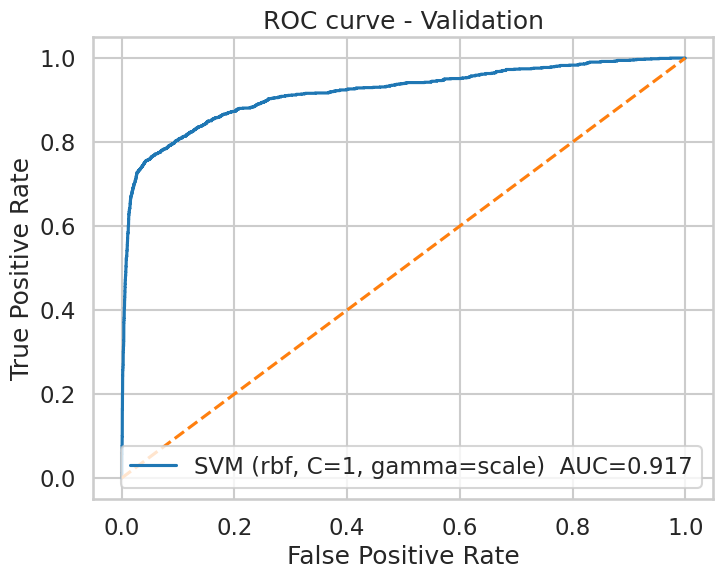


=== Interpretabilidad del modelo ===
El modelo no es lineal (p. ej., RBF), no existen coeficientes interpretables.
Calculando Permutation Importance sobre el conjunto de validación...

--- Top 15 características más influyentes (Permutation Importance) ---
loan_grade_G                   0.000523
loan_grade_F                   0.001262
loan_intent_PERSONAL           0.001489
loan_intent_VENTURE            0.001989
loan_intent_EDUCATION          0.002092
loan_intent_MEDICAL            0.002148
person_home_ownership_OWN      0.007923
loan_int_rate                  0.008764
loan_amnt                      0.011754
loan_grade_E                   0.012334
person_income                  0.013630
loan_intent_HOMEIMPROVEMENT    0.015880
person_home_ownership_RENT     0.020064
loan_percent_income            0.036240
loan_grade_D                   0.048369
dtype: float64


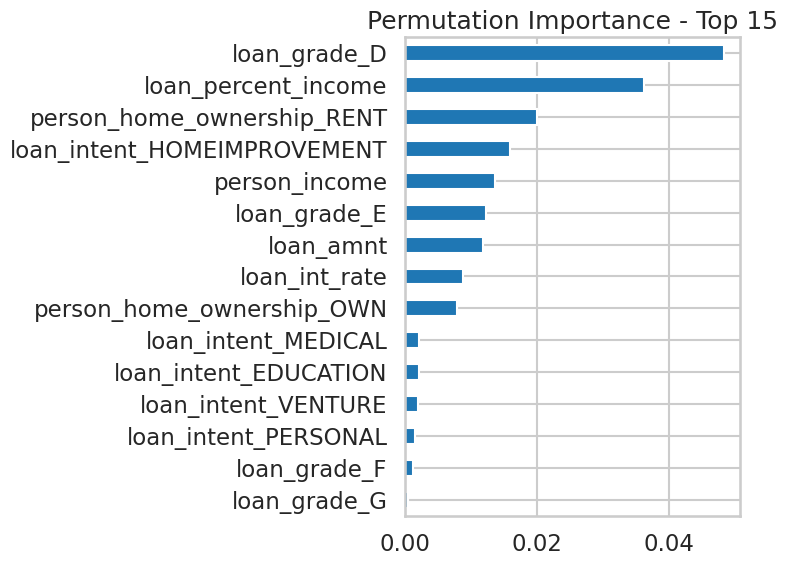

In [14]:
from sklearn.inspection import permutation_importance


best_model = grid.best_estimator_
svc = best_model.named_steps["svc"]  # clasificador dentro del pipeline

# Probabilidades y AUC
valid_proba = best_model.predict_proba(X_valid)[:, 1]
auc = roc_auc_score(y_valid, valid_proba)
print(f"AUC-ROC (valid): {auc:.4f}")

# (Opcional) métricas a umbral 0.5
valid_pred = (valid_proba >= 0.5).astype(int)
print("\nClassification report (threshold=0.5):")
print(classification_report(y_valid, valid_pred, digits=3))

# Curva ROC 
fpr, tpr, _ = roc_curve(y_valid, valid_proba)
label_kernel = f"SVM ({svc.kernel}"
if hasattr(svc, "C"): label_kernel += f", C={svc.C}"
if hasattr(svc, "gamma") and svc.kernel != "linear": label_kernel += f", gamma={svc.gamma}"
label_kernel += f")  AUC={auc:.3f}"

plt.figure()
plt.plot(fpr, tpr, label=label_kernel)
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve - Validation")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Interpretabilidad 
# Si el kernel es lineal -> coeficientes; si no -> permutation importance
print("\n=== Interpretabilidad del modelo ===")
if getattr(svc, "kernel", None) == "linear" and hasattr(svc, "coef_"):
    # Importancias según el hiperplano lineal (en el espacio escalado/one-hot)
    coefs = pd.Series(svc.coef_[0], index=feat_cols).sort_values()
    print("\n--- Top 15 señales NEGATIVAS (empujan a 0) ---")
    print(coefs.head(15))
    print("\n--- Top 15 señales POSITIVAS (empujan a 1) ---")
    print(coefs.tail(15))

    # (opcional) gráfico rápido de las 15 más influyentes por magnitud
    top_abs = coefs.abs().sort_values().tail(15)
    plt.figure()
    top_abs.plot(kind="barh")
    plt.title("Importancia (|coef|) - Top 15 (SVM lineal)")
    plt.tight_layout()
    plt.show()

else:
    print("El modelo no es lineal (p. ej., RBF), no existen coeficientes interpretables.")
    print("Calculando Permutation Importance sobre el conjunto de validación...")

    # Permutation importance sobre el pipeline completo
    pi = permutation_importance(
        best_model, X_valid, y_valid,
        n_repeats=10, random_state=42, n_jobs=-1
    )
    importances = pd.Series(pi.importances_mean, index=feat_cols).sort_values()

    print("\n--- Top 15 características más influyentes (Permutation Importance) ---")
    print(importances.tail(15))

    # gráfico de las 15 más influyentes
    top15 = importances.tail(15)
    plt.figure()
    top15.plot(kind="barh")
    plt.title("Permutation Importance - Top 15")
    plt.tight_layout()
    plt.show()


# Creación de csv de submit

In [15]:
import pandas as pd

# Obtener las probabilidades del modelo
test_proba = best_model.predict_proba(test_clean.values)[:, 1]

# Crear el DataFrame con el mismo formato que el sample_submission
submission = pd.DataFrame({
    "id": test["id"],              # los ids originales del test
    "loan_status": test_proba      # las probabilidades predichas
})


# guardar para enviar
submission.to_csv("submission.csv", index=False)

print("Archivo 'submission.csv' creado correctamente a partir de los datos de test!")
submission.head()


Archivo 'submission.csv' creado correctamente a partir de los datos de test!


,id,loan_status
0,43983,0.150155
1,43984,0.026542
2,43985,0.703398
3,43986,0.007429
4,43987,0.026719
